In [1]:
import pandas as pd
df = pd.read_csv("Raw_data/anonymized_clinical.csv")

In [2]:
# Explore the dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  20000 non-null  object 
 1   TIME_FROM_TX_TO_ASSESSMENT  20000 non-null  object 
 2   ANONYM_ASSESSMENT_DATE      20000 non-null  object 
 3   BP_SYSTOLIC_mmHG            19321 non-null  float64
 4   BP_DIASTOLIC_mmHg           19319 non-null  float64
 5   TEMPERATUR_DEG              6356 non-null   float64
 6   PULSE_PER_MIN               18734 non-null  float64
 7   URINE_VOL_L                 13600 non-null  float64
 8   REC_WT_KG                   19764 non-null  float64
dtypes: float64(6), object(3)
memory usage: 1.4+ MB


,BP_SYSTOLIC_mmHG,BP_DIASTOLIC_mmHg,TEMPERATUR_DEG,PULSE_PER_MIN,URINE_VOL_L,REC_WT_KG
count,19321.000000,19319.000000,6356.000000,18734.000000,13600.000000,19764.000000
mean,134.451478,82.425488,35.998932,74.072328,2310.857868,72.340434
std,17.421327,11.537038,0.431339,12.486655,658.561112,15.521993
min,75.000000,10.000000,34.000000,36.000000,0.000000,5.000000
25%,123.000000,75.000000,35.900000,65.000000,1900.000000,60.200000
50%,133.000000,82.000000,36.000000,72.000000,2200.000000,71.000000
75%,144.000000,90.000000,36.100000,81.000000,2700.000000,82.000000
max,243.000000,183.000000,42.000000,183.000000,7500.000000,168.000000


In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)

Patient_ID                        0
TIME_FROM_TX_TO_ASSESSMENT        0
ANONYM_ASSESSMENT_DATE            0
BP_SYSTOLIC_mmHG                679
BP_DIASTOLIC_mmHg               681
TEMPERATUR_DEG                13644
PULSE_PER_MIN                  1266
URINE_VOL_L                    6400
REC_WT_KG                       236
dtype: int64


In [7]:
# Summarizing the data per patient
patient_summary = df.groupby('Patient_ID').agg({
    'BP_SYSTOLIC_mmHG': ['mean', 'std'],
    'BP_DIASTOLIC_mmHg': ['mean', 'std'],
    'TEMPERATUR_DEG': ['mean', 'std'],
    'PULSE_PER_MIN': ['mean', 'std'],
    'URINE_VOL_L': ['mean', 'std'],
    'REC_WT_KG': ['mean', 'std']
}).reset_index()
print(patient_summary)

    Patient_ID BP_SYSTOLIC_mmHG            BP_DIASTOLIC_mmHg             \
                           mean        std              mean        std   
0        P1000       118.465116  16.560637         84.395349  10.852122   
1        P1001       144.682927  18.263952         73.536585   8.535507   
2        P1002       126.687500   9.540921         86.750000   8.947998   
3        P1003       126.279070  11.274804         75.302326   6.758123   
4        P1004       131.682927  14.680026         86.670732   8.869500   
..         ...              ...        ...               ...        ...   
307      P1307       134.302083  15.129699         77.854167  12.500088   
308      P1308       102.750000  13.961799         64.750000   6.077155   
309      P1309       128.540816  13.009250         89.255102   7.999112   
310      P1310       125.495238  13.584581         84.590476  10.106829   
311      P1311       148.121212  10.224840         88.303030   5.950236   

    TEMPERATUR_DEG      

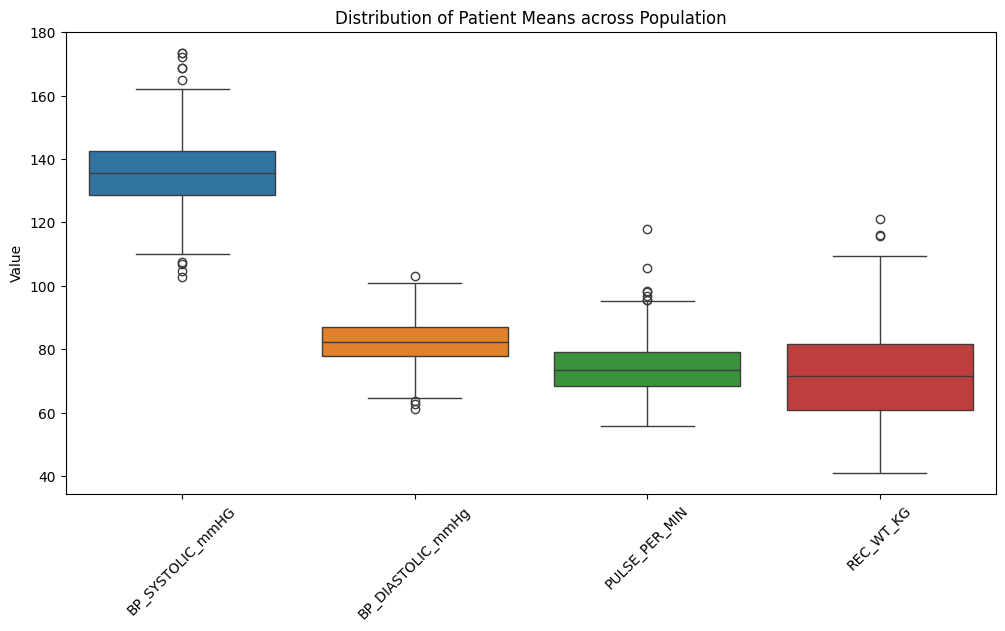

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transpose the patient summary for easier plotting
df_plot = patient_summary.T

# Boxplot of Means to see the spread across the population
vitals = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'PULSE_PER_MIN', 'REC_WT_KG']
plt.figure(figsize=(12, 6))
sns.boxplot(data=patient_summary[vitals].xs('mean', axis=1, level=1))
plt.title('Distribution of Patient Means across Population')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()

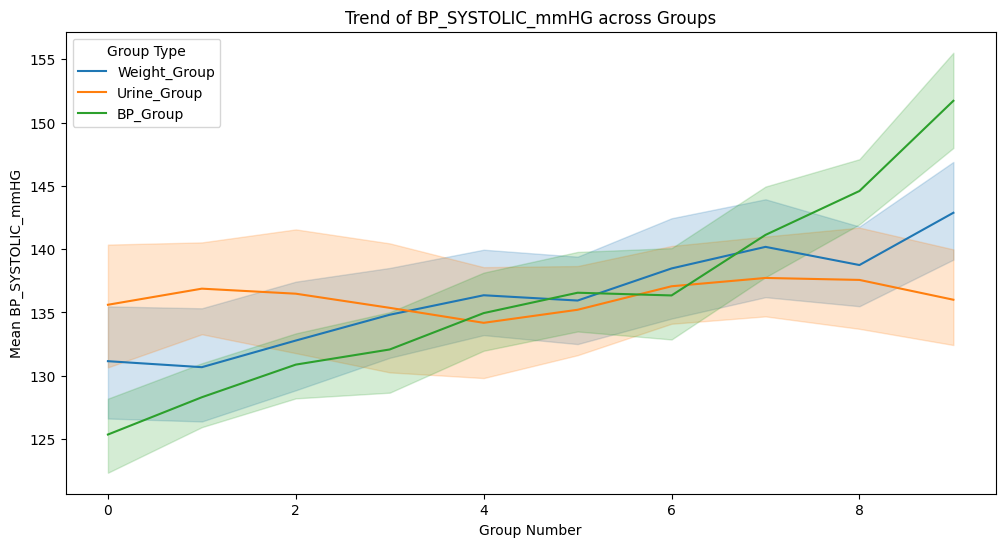

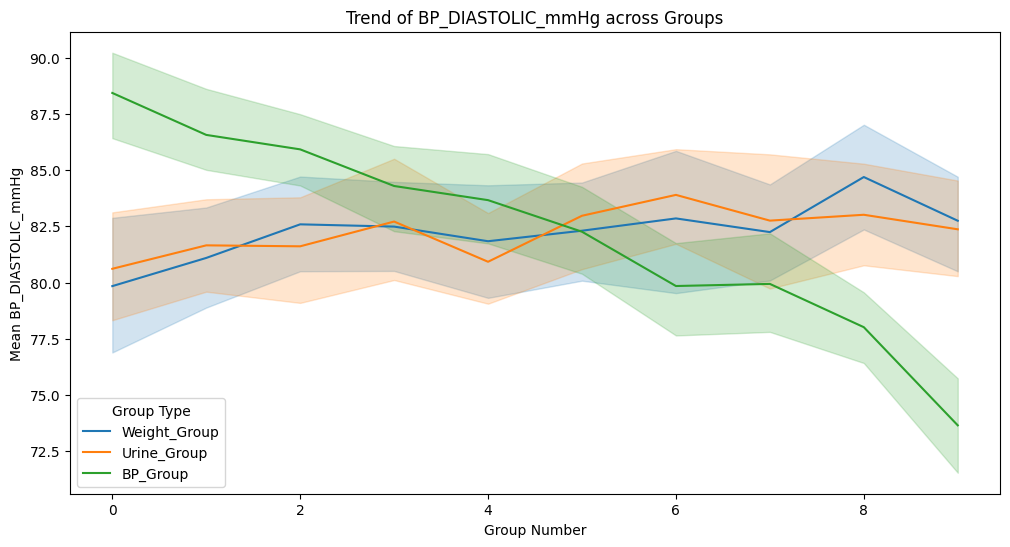

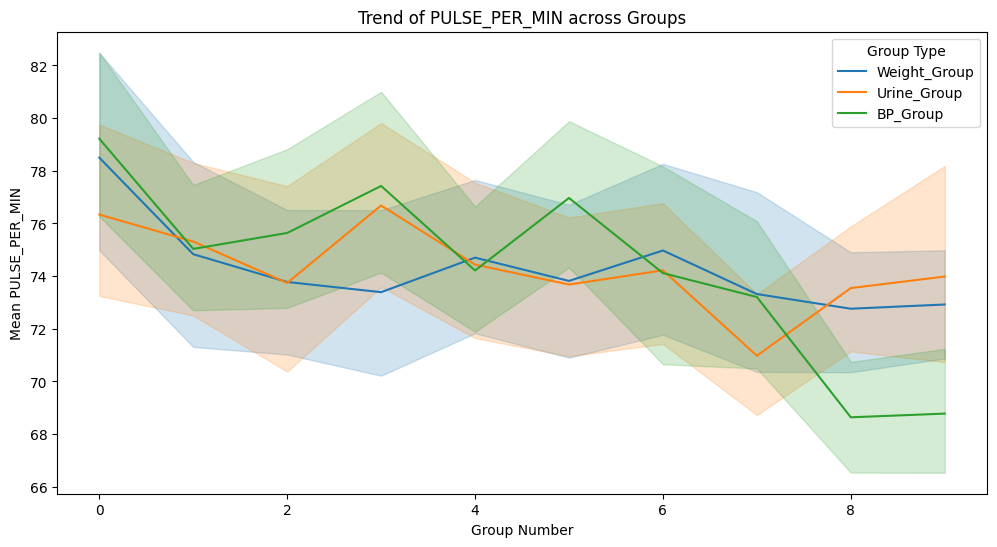

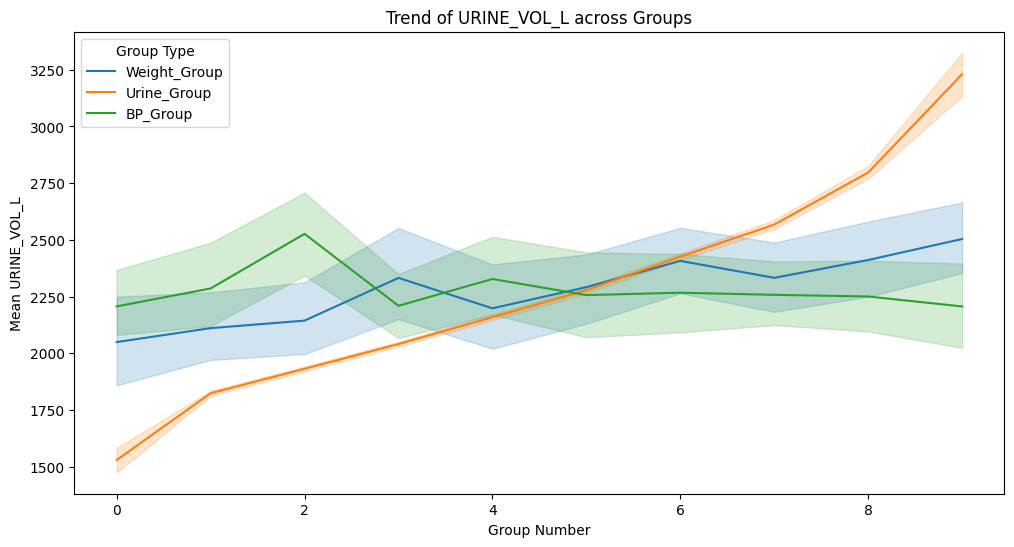

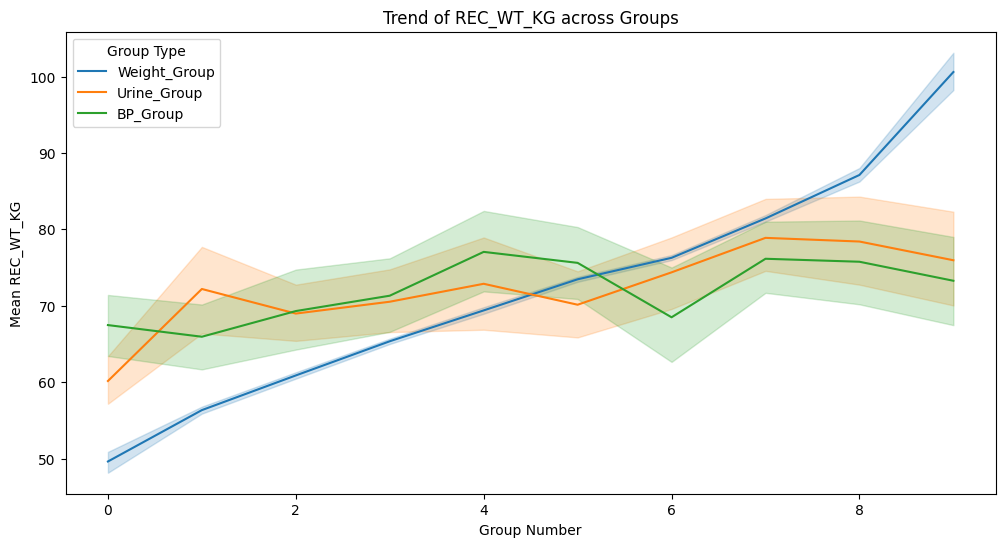

In [19]:
# Visualize the clinical trends of weight, blood pressure, and urine volume 
# Categorize the patients based on their mean weight, blood pressure, urine volume into 10 groups
patient_summary['Weight_Group'] = pd.qcut(patient_summary[('REC_WT_KG', 'mean')], q=10, labels=False)
patient_summary['Urine_Group'] = pd.qcut(patient_summary[('URINE_VOL_L', 'mean')], q=10, labels=False)

# Categorize the patients based on their mean blood pressure into 10 groups considering 
# both systolic and diastolic and merge them in the same group
patient_summary['BP_Group'] = pd.qcut(patient_summary[('BP_SYSTOLIC_mmHG', 'mean')] / patient_summary[('BP_DIASTOLIC_mmHg', 'mean')], q=10, labels=False)

# Plot the trends for each vital sign in different plot using for loop, one for each vital sign, using the x as group number instead of patient id.
vital_signs = ['BP_SYSTOLIC_mmHG', 'BP_DIASTOLIC_mmHg', 'PULSE_PER_MIN', 'URINE_VOL_L', 'REC_WT_KG']
groups = ['Weight_Group', 'Urine_Group', 'BP_Group']
for vital in vital_signs:
    plt.figure(figsize=(12, 6))
    for group in groups:
        sns.lineplot(x=group, y=(vital, 'mean'), data=patient_summary, label=group)
    plt.title(f'Trend of {vital} across Groups')
    plt.ylabel(f'Mean {vital}')
    plt.xlabel('Group Number')
    plt.legend(title='Group Type')
    plt.show()

In [ ]:
# Also, let me know whether patients show stabilization of vitals in 
# the first months after transplant. If yes, what's the general trend?

# Do you find some correlations between Clinical Variables

# Which vital sign can be a key indicator of graft function?
